In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, chi2, f_classif

DATA COLLECTION

In [11]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

DATA PREPROCESSING & CLEANING

In [12]:
df_clean = df.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1)
le = LabelEncoder()
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = le.fit_transform(df_clean[col])

X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

EXPLORATORY DATA ANALYSIS

In [13]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

1. Target Distribution

C:\Users\gayat\AppData\Local\Temp\ipykernel_21684\3707360990.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette='viridis')


Text(0.5, 1.0, 'Attrition Distribution (Target)')

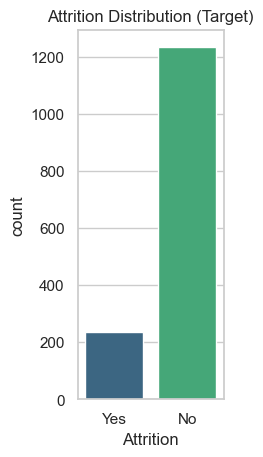

In [14]:
plt.subplot(1, 3, 1)
sns.countplot(x='Attrition', data=df, palette='viridis')
plt.title('Attrition Distribution (Target)')

2. Overtime vs Attrition

Text(0.5, 1.0, 'Impact of Overtime on Attrition')

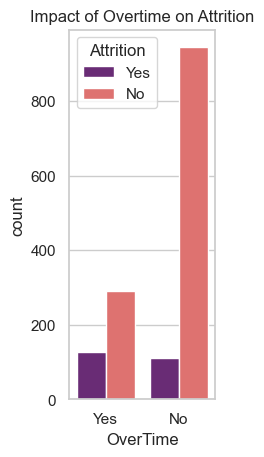

In [15]:
plt.subplot(1, 3, 2)
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='magma')
plt.title('Impact of Overtime on Attrition')

3. Monthly Income vs Attrition

C:\Users\gayat\AppData\Local\Temp\ipykernel_21684\612909539.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='plasma')


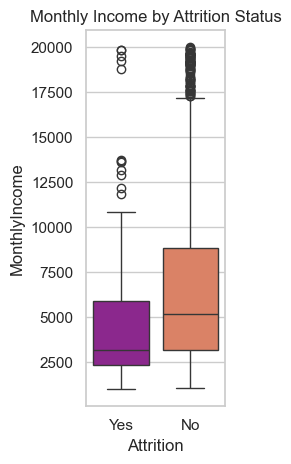

In [17]:
plt.subplot(1, 3, 3)
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='plasma')
plt.title('Monthly Income by Attrition Status')
plt.tight_layout()
plt.show()

Correlation Analysis

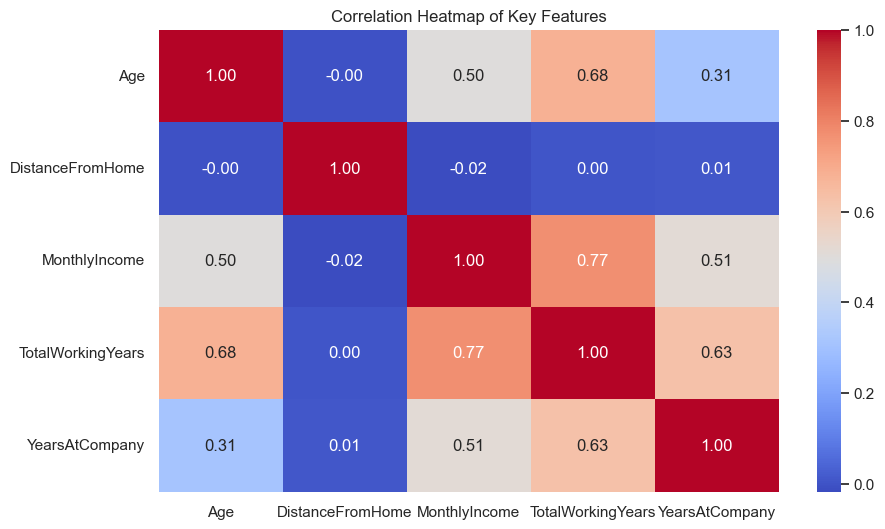

In [18]:
plt.figure(figsize=(10, 6))
num_features = ['Age', 'DistanceFromHome', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany']
sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Key Features')
plt.show()

FEATURE ENGINEERING & SELECTION

In [19]:
anova_selector = SelectKBest(f_classif, k=10).fit(X, y)
chi_selector = SelectKBest(chi2, k=10).fit(X, y)

MODEL TRAINING

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
dtree = DecisionTreeClassifier(random_state=42)
# Best Model: XGBoost
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42, eval_metric='logloss')

log_reg.fit(X_train_scaled, y_train)
dtree.fit(X_train, y_train)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

MODEL EVALUATION & COMPARISON

In [27]:
model_list = {'Logistic Regression': (log_reg, X_test_scaled), 'Decision Tree': (dtree, X_test), 'XGBoost': (xgb, X_test)}

print("\nModel Performance Comparison:")
for name, (model, xt) in model_list.items():
    preds = model.predict(xt)
    print(f"{name} -> Accuracy: {accuracy_score(y_test, preds):.4f}, F1-Score: {f1_score(y_test, preds):.4f}")


Model Performance Comparison:
Logistic Regression -> Accuracy: 0.8741, F1-Score: 0.4932
Decision Tree -> Accuracy: 0.7823, F1-Score: 0.3191
XGBoost -> Accuracy: 0.8605, F1-Score: 0.3692


BEST MODEL

In [28]:
print("\nSelected Best Model: XGBoost")
y_pred_xgb = xgb.predict(X_test)


Selected Best Model: XGBoost


Confusion Matrix

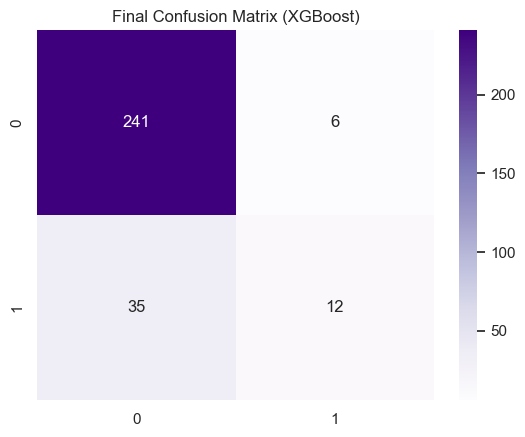

In [29]:
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Purples')
plt.title('Final Confusion Matrix (XGBoost)')
plt.show()

Feature Importance for HR Insight

C:\Users\gayat\AppData\Local\Temp\ipykernel_21684\2844850727.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances.head(10), palette='rocket')


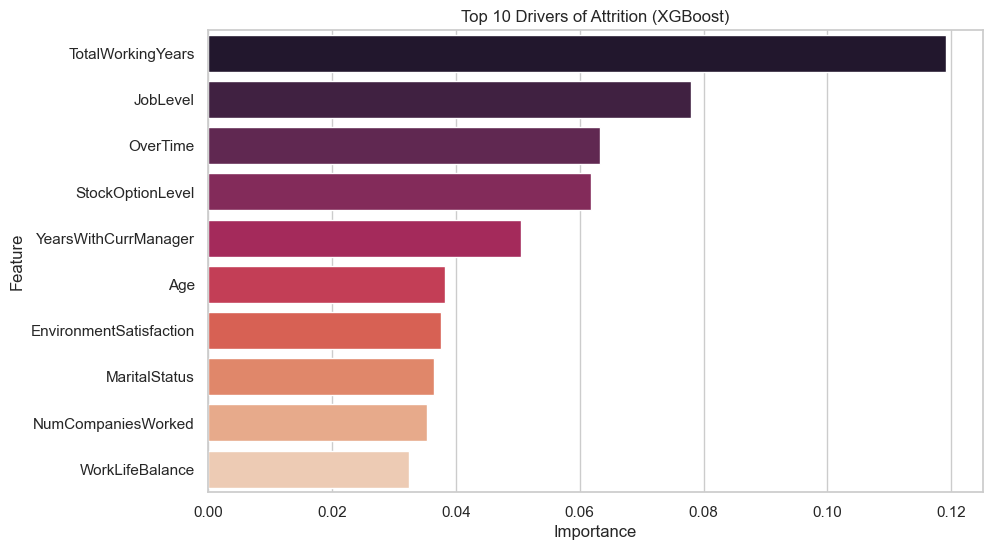

In [30]:
importances = pd.DataFrame({'Feature': X.columns, 'Importance': xgb.feature_importances_}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances.head(10), palette='rocket')
plt.title('Top 10 Drivers of Attrition (XGBoost)')
plt.show()